# 零基础实战机器学习 源代码

作者 黄佳

极客时间专栏链接：https://time.geekbang.org/column/intro/438

用户的消费行为本身是不能直接用于数据分析的，这就需要我们把用户的行为转化成具体的数值，也就是可量化的指标，让我们对用户有更直观的认识。而且我们还可以将这些指标用在数据分析、广告精准投放、产品推荐系统等多个运营场景，来提升我们产品和服务的精准度。

这个具体的数值呢，就是 RFM（Recency、Frequency、Monetary ），它是用户画像的衍生品，也是目前很多互联网厂商普遍采用的分析方式。具体来看：

* R 是新进度，代表自用户上次消费以来的天数。这个指标其实也就是用户的热乎度，比如说你上次使用 App 是一个月前，你的系统里 R 值就是 30。如果你今天又用了一次 App，那 R 值就会立刻被更新为 1；
* F 是消费频率，代表用户是否频繁使用服务。这也是用户黏性的风向标；
* M 是消费金额，代表用户在一段时间内消费的总金额，这个不难理解。

通过用户消费行为的新进度、消费的总体频率，还有消费总金额这三项指标，我们可以将用户划分为不同的类别或集群，来直观地描述用户的价值。什么意思呢？简单来说就是，只要我们从用户的基本信息和消费行为数据中得出 RFM 值，就可以根据它对用户分组画像了。

所以，我们这个项目整体上可以分为两个阶段：第一个阶段是求出 `RFM` 值，第二个阶段就是利用 `RFM` 值，给用户分组画像，进而绘制出高价值、中等价值和低价值用户的分布情况。我们今天这节课的目标就是解决第一阶段的问题。

## 导入数据

In [1]:
import pandas as pd #导入Pandas
df_sales = pd.read_csv('易速鲜花订单记录.csv') #载入数据
df_sales.head() #显示头几行数据 

,订单号,产品码,消费日期,产品说明,数量,单价,用户码,城市
0,536374,21258,6/1/2020 9:09,五彩玫瑰五支装,32,10.95,15100,北京
1,536376,22114,6/1/2020 9:32,茉莉花白色25枝,48,3.45,15291,上海
2,536376,21733,6/1/2020 9:32,教师节向日葵3枝尤加利5枝,64,2.55,15291,上海
3,536378,22386,6/1/2020 9:37,百合粉色10花苞,10,1.95,14688,北京
4,536378,85099C,6/1/2020 9:37,橙黄香槟色康乃馨,10,1.95,14688,北京


可以看到这个数据集主要包含了订单号、产品码、消费日期，产品说明、数量、单价、用户码和城市等字段。因为我们求的是用户消费行为的新进度（R）、消费的总体频率（F），还有消费总金额（M），所以在这些信息中，我们重点关注的是以下几个数据：
* 用户码
* 单价
* （订单中产品的）数量
* 消费日期

## 数据可视化

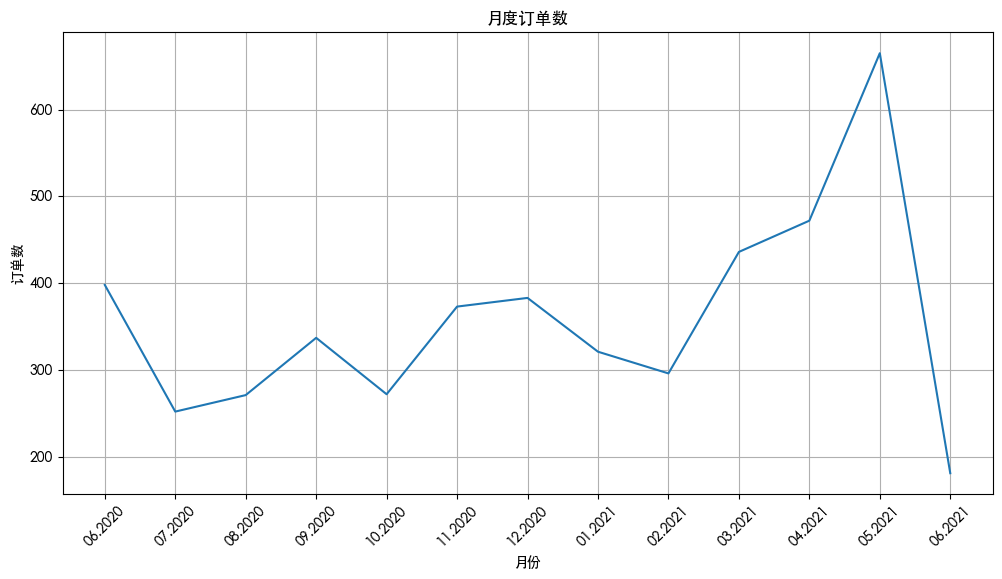

In [2]:
import matplotlib.pyplot as plt #导入Matplotlib的pyplot模块

from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

#构建月度的订单数的DataFrame
df_sales['消费日期'] = pd.to_datetime(df_sales['消费日期']) #转化日期格式
df_orders_monthly = df_sales.set_index('消费日期')['订单号'].resample('ME').nunique()
#设定绘图的画布
ax = pd.DataFrame(df_orders_monthly.values).plot(grid=True,figsize=(12,6),legend=False)
ax.set_xlabel('月份') # X轴label
ax.set_ylabel('订单数') # Y轴Label
ax.set_title('月度订单数') # 图题
#设定X轴月份显示格式
plt.xticks(
    range(len(df_orders_monthly.index)), 
    [x.strftime('%m.%Y') for x in df_orders_monthly.index], 
    rotation=45)
plt.show() # 绘图

我们看到，这个数据集收集了“易速鲜花”公司一整年的订单量。所以啊，我们要求的消费额 M，实际上是每个用户一整年的总消费额。

你可能已经注意到，在最后一个月，也就是 2021 年 6 月，订单量突然大幅下降。其实这是因为运营人员拉这个表的时候，正是 6 月的第一个礼拜。所以，6 月的数据虽然不全，但并不会影响我们对用户 RFM 值的分析。

## 数据清洗

In [6]:
df_sales = df_sales.drop_duplicates() #删除重复的数据行

In [7]:
df_sales.isna().sum() # NaN出现的次数

订单号     0
产品码     0
消费日期    0
产品说明    0
数量      0
单价      0
用户码     0
城市      0
dtype: int64

In [8]:
df_sales.describe() #df_sales的统计信息

,消费日期,数量,单价,用户码
count,85920,85920.000000,85920.000000,85920.000000
mean,2021-01-04 22:50:58.891759616,10.115747,3.599711,15338.080389
min,2020-06-01 09:09:00,-9360.000000,0.000000,14681.000000
25%,2020-10-03 12:42:00,2.000000,1.250000,15022.000000
50%,2021-01-22 11:45:00,4.000000,1.950000,15334.000000
75%,2021-04-19 13:58:00,12.000000,3.750000,15673.000000
max,2021-06-09 12:31:00,3114.000000,38970.000000,16019.000000
std,NaN,49.114285,134.410498,391.309086


在图中你可以看到这个数据集中，共有 9 万多行的数据（count 统计数据条目的数量），每条数据的平均采购数量是 10（mean 统计均值），商品平均单价是 3.575 元左右。在概览中我们发现，（订单中产品的）数量的最小值（min）是一个负数（-9360），这显然是不符合逻辑的，所以我们要把这种脏数据清洗掉。

具体的处理方式是，用 loc 属性通过字段名（也就是列名）访问数据集，同时只保留“数量”字段大于 0 的数据行：

In [9]:
df_sales = df_sales.loc[df_sales['数量'] > 0] #清洗掉数量小于等于0的数据

在 DataFrame 对象中，loc 属性是通过行、列的名称来访问数据的，我们做数据预处理时会经常用到；还有一个常被用到的属性是 iloc，它是通过行列的位置（也就是序号）来访问数据的。由于数据行的名称往往也是数值，这两者非常容易被弄混。

所以，在这里我特地给你做了一张图，来说明什么是行列名、什么是行列序号，帮你弄清楚它们的区别。

![](https://static001.geekbang.org/resource/image/e4/de/e4165807e638ac602fb64fab28a0b8de.jpg)

In [10]:
df_sales.describe() #df_sales的统计信息

,消费日期,数量,单价,用户码
count,84112,84112.000000,84112.000000,84112.000000
mean,2021-01-05 01:14:46.564342784,10.760236,3.005032,15337.732963
min,2020-06-01 09:09:00,1.000000,0.000000,14681.000000
25%,2020-10-03 12:42:00,2.000000,1.250000,15021.000000
50%,2021-01-22 11:45:00,5.000000,1.950000,15333.000000
75%,2021-04-19 15:08:00,12.000000,3.750000,15674.000000
max,2021-06-09 12:31:00,3114.000000,3155.950000,16019.000000
std,NaN,34.018906,15.365085,392.074855


再用一次 describe 方法，就会看到新的最小数量为 1，这就对了。

## 特征工程

In [11]:
df_sales['总价'] = df_sales['数量'] * df_sales['单价'] #计算每单的总价
df_sales.head() #显示头几行数据  

,订单号,产品码,消费日期,产品说明,数量,单价,用户码,城市,总价
0,536374,21258,2020-06-01 09:09:00,五彩玫瑰五支装,32,10.95,15100,北京,350.4
1,536376,22114,2020-06-01 09:32:00,茉莉花白色25枝,48,3.45,15291,上海,165.6
2,536376,21733,2020-06-01 09:32:00,教师节向日葵3枝尤加利5枝,64,2.55,15291,上海,163.2
3,536378,22386,2020-06-01 09:37:00,百合粉色10花苞,10,1.95,14688,北京,19.5
4,536378,85099C,2020-06-01 09:37:00,橙黄香槟色康乃馨,10,1.95,14688,北京,19.5


现在，在这个数据集中，用户码、总价和消费日期这三个字段，给我们带来了每一个用户的 R、F、M 信息。其中：
* 一个用户上一次购物的日期，也就是最新的消费日期，就可以转化成这个用户的 R 值；
* 一个用户下的所有订单次数之和，就是消费频率值，也就是该用户的 F 值；
* 把一个用户所有订单的总价加起来，就是消费金额值，也就是该用户的 M 值。

不过，我们目前的这个数据集是一个订单的历史记录，并不是以用户码为主键的数据表。而 R、F、M 信息是和用户相关的，每一个用户都拥有一个独立的 R 值、F 值和 M 值，所以，在计算 RFM 值之前，我们需要先构建一个用户层级表。

## 构建User用户表

In [12]:
df_user = pd.DataFrame(df_sales['用户码'].unique()) #生成以用户码为主键的结构df_user
df_user.columns = ['用户码'] #设定字段名
df_user = df_user.sort_values(by='用户码',ascending=True).reset_index(drop=True) #按用户码排序
df_user #显示df_user

,用户码
0,14681
1,14682
2,14684
3,14687
4,14688
...,...
975,16015
976,16016
977,16017
978,16018


构建用户层级表，简单来说就是生成一个以用户码为关键字段的 Dataframe 对象 df_user，然后在这个 Dataframe 对象中，逐步加入每一个用户的新近度（R）、消费频率（F）、消费金额（M），以及最终总的分组信息。

## 求R值

In [13]:
df_sales['消费日期'] = pd.to_datetime(df_sales['消费日期']) #转化日期格式
df_recent_buy = df_sales.groupby('用户码').消费日期.max().reset_index() #构建消费日期信息
df_recent_buy.columns = ['用户码','最近日期'] #设定字段名
df_recent_buy['R值'] = (df_recent_buy['最近日期'].max() - df_recent_buy['最近日期']).dt.days #计算最新日期与上次消费日期的天数
df_user = pd.merge(df_user, df_recent_buy[['用户码','R值']], on='用户码') #把上次消费距最新日期的天数（R值）合并至df_user结构
df_user.head() #显示df_user头几行数据

,用户码,R值
0,14681,70
1,14682,187
2,14684,25
3,14687,106
4,14688,7


R 值越大，说明该用户最近一次购物日距离当前日期越久，那么这样的用户就越是处于休眠状态。从表中可以看出来，编号为 14682 的用户已经有 187 天没有购物了。所以我们就可以判断这个用户呈现休眠态，很可能已经被别的购物平台所吸引了，也就是流失了。

## 求F值

In [14]:
df_frequency = df_sales.groupby('用户码').消费日期.count().reset_index() #计算每个用户消费次数，构建df_frequency对象
df_frequency.columns = ['用户码','F值'] #设定字段名称
df_user = pd.merge(df_user, df_frequency, on='用户码') #把消费频率整合至df_user结构
df_user.head() #显示头几行数据

,用户码,R值,F值
0,14681,70,7
1,14682,187,2
2,14684,25,390
3,14687,106,15
4,14688,7,324


## 求M值

In [15]:
df_revenue = df_sales.groupby('用户码').总价.sum().reset_index() #根据消费总额，构建df_revenue对象
df_revenue.columns = ['用户码','M值'] #设定字段名称
df_user = pd.merge(df_user, df_revenue, on='用户码') #把消费金额整合至df_user结构
df_user.head() #显示头几行数据

,用户码,R值,F值,M值
0,14681,70,7,498.95
1,14682,187,2,52.00
2,14684,25,390,1201.51
3,14687,106,15,628.38
4,14688,7,324,5579.10


要做分组画像，RFM 分析是一个不错的方法，它也是目前很多互联网厂商普遍采用的分析方式。我们今天的重点是，根据用户码、总价和消费日期这三个字段，从消费历史数据中求出每位用户的 R、F、M 的值，这就好像给用户贴上了一堆数字化的标签。

同时，用户行为的量化，也可以视作是进一步做机器学习项目之前的特征工程。这也为我们后续给用户做聚类分组做好了准备。